# Data exploration - DL Reaction time HW

### What could affect reaction time?
* Intuitively: Distance traveled with the eyes could be very indicative. When I search for something (e.g. "the" in a text), my eyes jump a lot around the screen until I find it. Then, when I found it, the last step is quite small. Then you stay on it (longer fixated)
* Distance:
    * Large jumps → exploration
    * Small jumps → focused inspection
    * Early large jumps + later small jumps = efficient
    * Random jumps throughout = inefficient
* Time:
    * More randomness in eye movement -> More reaction time
    * Short fixations = scanning / uncertainty
    * Many long fixations → difficult task → slower RT
    * Very short noisy fixations → confusion → slower RT
* Revisiting same region: Uncertainty -> Longer RT
* Spatial coverage
    * Good search: structured coverage (grid-like, systematic)
    * Bad search: clustered or chaotic
* Behavior over time:
    * Early chaos → later focus → fast RT
    * Always chaotic → slow RT


### Insights

* 46 occurrences where reaction time is 0.0 -> Always length of sequence = 1

* Number of fixations = strong feature. High correlation with reaction time.
    * Evidently also the sum of durations (but NOT the mean of durations).
* Multimodality: Reaction times have a second mode near 10s. The max. duration is almost exactly 10s.
    * It does not seem like a cut-off, as many points are there.
    * nn.SmoothL1Loss() could be a good loss function
    * Can't use tricks that I'd use for multimodal feature
* Hardly skewed input features: Fixation duration and number of fixations.
    * Log transform them: d_log = np.log1p(FPOGD), then x = (x - mean) / std
    * Distance and duration are heavily right-skewed. Using np.log1p helps to stretch them out a bit more.
    * Some global features are also skewed, like len(df)
* Histogram of sine(theta) and cosine(theta) show peaks at 0 and +-1, which suggests that eye movements are not completely random, but are more horizontal or vertical scans (structures).
* Distance features:
    * Distance sum (dist.sum()): corr 0.85
    * Linear trend negatively correlated with -0.51
        * Code: t = np.arange(len(dist)); slope = np.polyfit(t, dist, 1)[0]
    * Distance travelled in first third of sequence
    * Distance max
    * .... There is more, but maybe focus on just these.
* Duration features:
    * Sum of durations (see above)
    * Number of switches (dur_switches): 0.77 (switches w.r.to median plus a 20-quantile-band hysteresis)
    * Max duration time (hard moment in sequence)
    * dur_diff_std = np.abs(np.diff(durations)), with a correlation of 0.41
    * (maybe dur_p10, because very small fixations)
* Spatial features (all very high potential):
    * spatial_revisit_ratio
    * spatial_coverage_ratio
    * Spatial_entropy_norm
    * spatial_angle_std.
    * spatial_hull_area

In [163]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob

### Load data

In [164]:
def load_csv(file_path, header='infer', names=None):
    df = pd.read_csv(file_path, sep=r"\s+", header=header, names=names)
    return df

In [165]:
DATA_DIR = "scanpaths_split/train_val/"

scanpaths = glob(os.path.join(DATA_DIR, "*.csv"))
print(f"scanpaths: {len(scanpaths)} files")

metadata = load_csv("scanpaths_split/train_val_labels.csv", header=None, names=['reaction_time', "filename"])
rt_dict = dict(zip(metadata.iloc[:, 1], metadata.iloc[:, 0]))

scanpaths: 3696 files


In [166]:
df = load_csv(scanpaths[0])
print(scanpaths[0])
df.head()

scanpaths_split/train_val/23-19.csv


,FPOGX,FPOGY,FPOGD
0,0.57310,0.27285,0.19467
1,0.33746,0.71241,0.22684
2,0.37297,0.73051,0.27414
3,0.38916,0.72370,0.37250
4,0.56965,0.26571,0.24283


### Visualize scanpaths of random samples

In [167]:
def plot_fixation_and_reaction_times(df, title=None):
    x = df["FPOGX"].values
    y = df["FPOGY"].values
    d = df["FPOGD"].values  # duration

    plt.figure(figsize=(6, 6))

    # Plot scanpath (lines between fixations)
    plt.plot(x, y, '-', alpha=0.5, linewidth=1)

    # Plot fixations (size = duration)
    sizes = 200 * (d / d.max())  # normalize for visibility
    plt.scatter(x, y, s=sizes, c=np.arange(len(x)), cmap="viridis", alpha=0.8)

    # Add duration labels
    for i in range(len(x)):
        plt.text(
            x[i], y[i],
            f"{d[i]:.2f}",   # format to 2 decimals
            fontsize=7,
            ha='center',
            va='center'
        )

    # Mark start and end
    plt.scatter(x[0], y[0], c='green', s=100, label="Start")
    plt.scatter(x[-1], y[-1], c='red', s=100, label="End")

    # Optional: annotate order (can get messy for long sequences)
    #for i in range(len(x)):
    #    plt.text(x[i], y[i], str(i), fontsize=6)

    plt.gca().invert_yaxis()  # important for screen coordinates
    plt.title(title if title else "Scanpath")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

In [168]:
def reaction_time_lookup(file_path):
    filename = os.path.basename(file_path)
    return rt_dict[filename]

3.49254


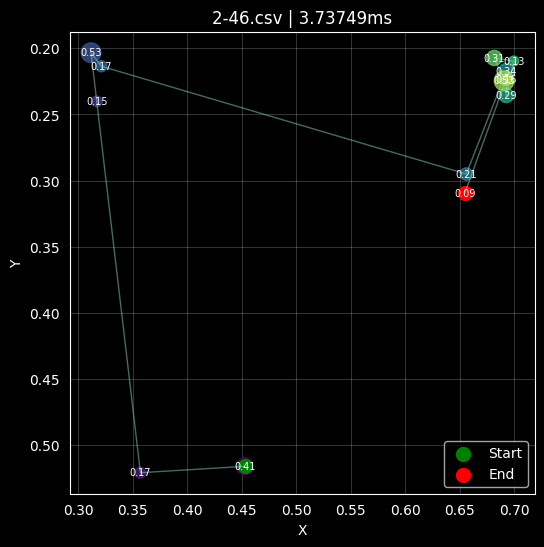

In [169]:
import random
import pandas as pd

idx = random.randint(0, len(scanpaths) - 1)
df = load_csv(scanpaths[idx])
print(df["FPOGD"].sum())

plot_fixation_and_reaction_times(df, title=f"{os.path.basename(scanpaths[idx])} | {reaction_time_lookup(scanpaths[idx])}ms")

## Statistics

### Feature and label distributions

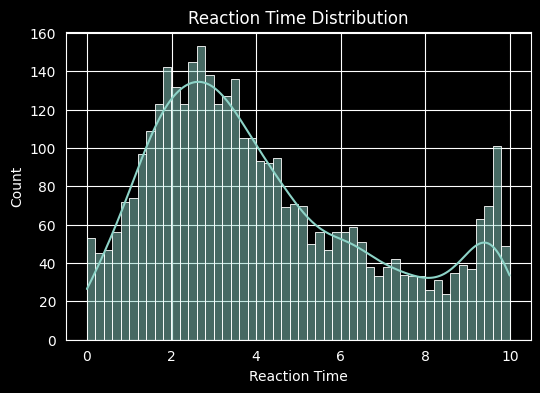

In [170]:
reaction_times = metadata.iloc[:, 0].values

plt.figure(figsize=(6,4))
sns.histplot(reaction_times, bins=50, kde=True)
plt.title("Reaction Time Distribution")
plt.xlabel("Reaction Time")
plt.ylabel("Count")
plt.show()

The mode on the right-hand side is making me think if that's the time where people give up or where it was cut-off maybe?

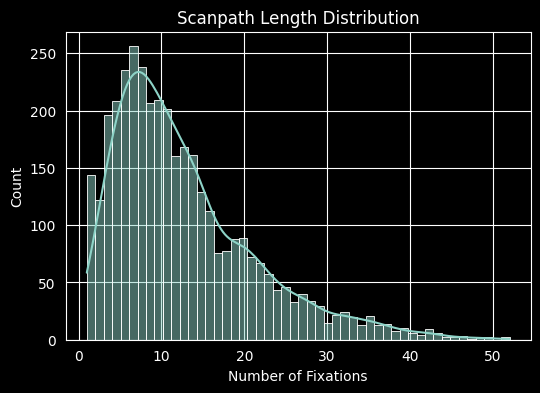

In [171]:
lengths = []

for path in scanpaths:
    df = load_csv(path)
    lengths.append(len(df))
    #lengths.append(np.log1p(len(df)))

plt.figure(figsize=(6,4))
sns.histplot(lengths, bins=50, kde=True)
plt.title("Scanpath Length Distribution")
plt.xlabel("Number of Fixations")
plt.show()

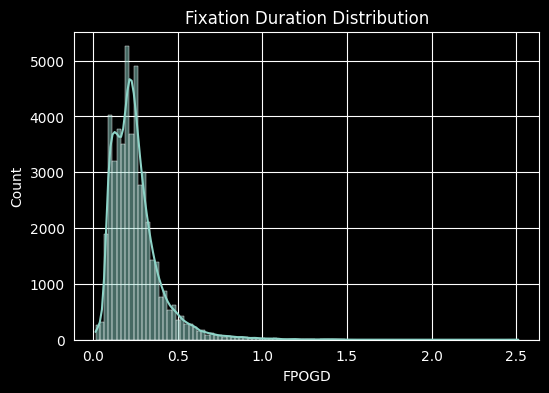

In [172]:
durations = []

for path in scanpaths:
    df = load_csv(path)
    durations.extend(df["FPOGD"].values)

plt.figure(figsize=(6,4))
sns.histplot(durations, bins=100, kde=True)
plt.title("Fixation Duration Distribution")
plt.xlabel("FPOGD")
plt.show()

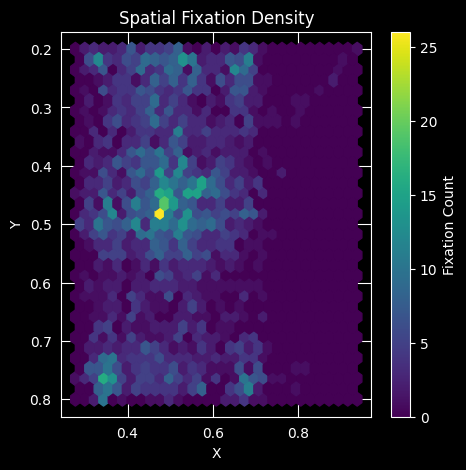

In [173]:
all_x, all_y = [], []

for path in scanpaths[:200]:  # subset for speed
    df = load_csv(path)
    all_x.extend(df["FPOGX"].values)
    all_y.extend(df["FPOGY"].values)

plt.figure(figsize=(5,5))
hb = plt.hexbin(all_x, all_y, gridsize=30, cmap='viridis')
plt.colorbar(hb, label="Fixation Count")
plt.title("Spatial Fixation Density")
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().invert_yaxis()
plt.show()

## Histograms of advanced features I will use for the model

Important to know which are skewed, so we can e.g. use log on them

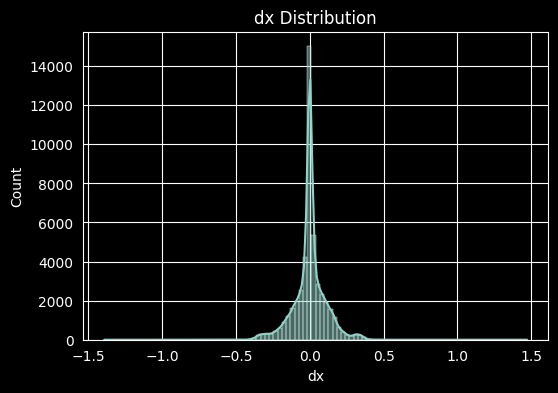

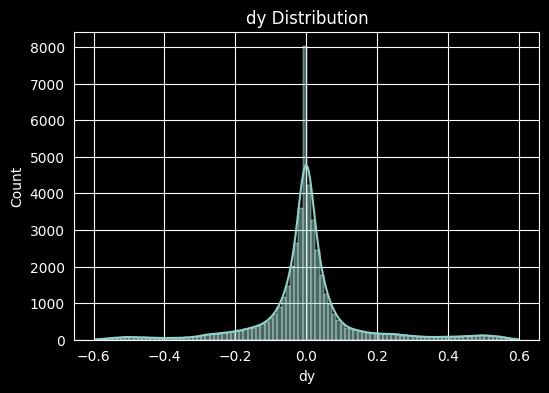

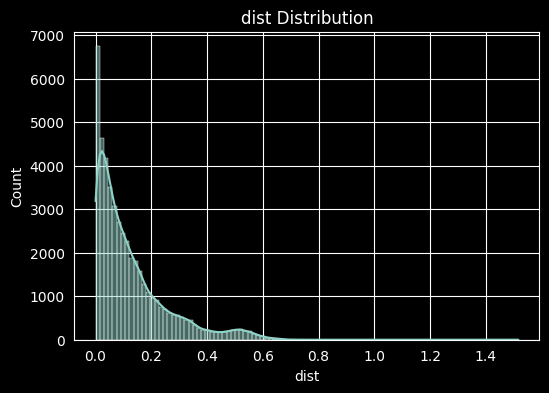

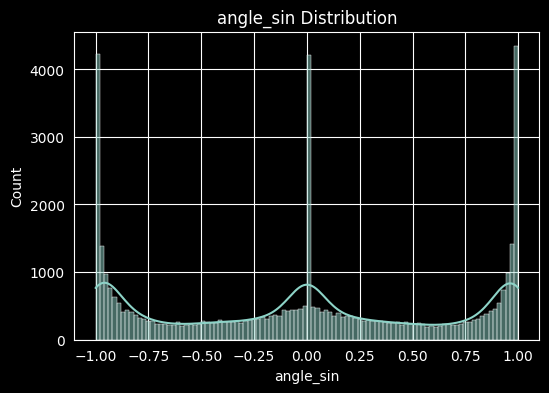

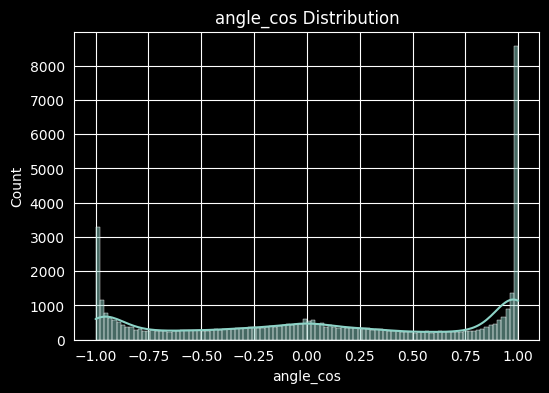

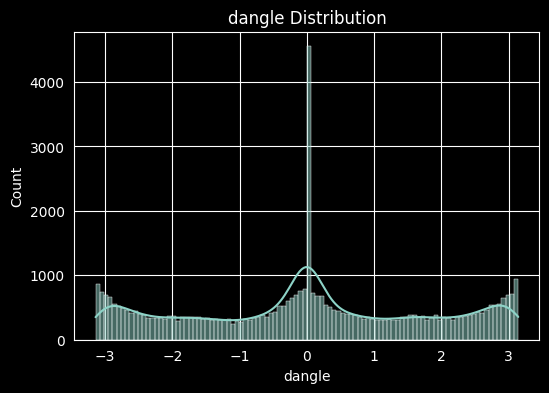

In [174]:
feature_store = {
    "dx": [],
    "dy": [],
    "dist": [],
    "angle_sin": [],
    "angle_cos": [],
    "dangle": [],
}

for path in scanpaths:
    df = load_csv(path)

    x = df["FPOGX"].values.astype(np.float32)
    y = df["FPOGY"].values.astype(np.float32)

    dx = np.diff(x, prepend=x[0])
    dy = np.diff(y, prepend=y[0])

    dist = np.sqrt(dx**2 + dy**2)

    angle = np.arctan2(dy, dx)
    angle_sin = np.sin(angle)
    angle_cos = np.cos(angle)

    # Unwrap to avoid heavy jumps like from +pi to -pi. Unwrapped goes smoothly around.
    angle_unwrapped = np.unwrap(angle)
    dangle = np.diff(angle_unwrapped, prepend=angle_unwrapped[0])

    feature_store["dx"].extend(dx)
    feature_store["dy"].extend(dy)
    feature_store["dist"].extend(dist)
    feature_store["angle_sin"].extend(angle_sin)
    feature_store["angle_cos"].extend(angle_cos)
    feature_store["dangle"].extend(dangle)

for feature_name, values in feature_store.items():
    plt.figure(figsize=(6,4))
    sns.histplot(values, bins=100, kde=True)
    plt.title(f"{feature_name} Distribution")
    plt.xlabel(feature_name)
    plt.show()

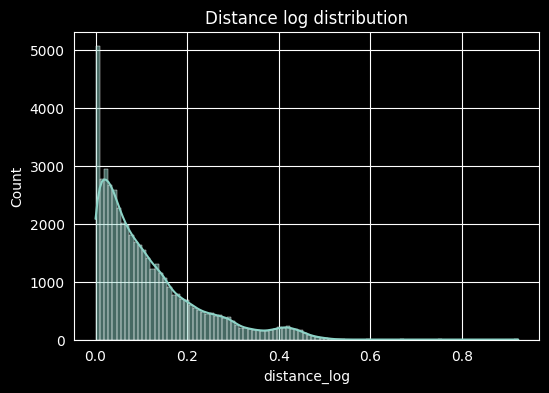

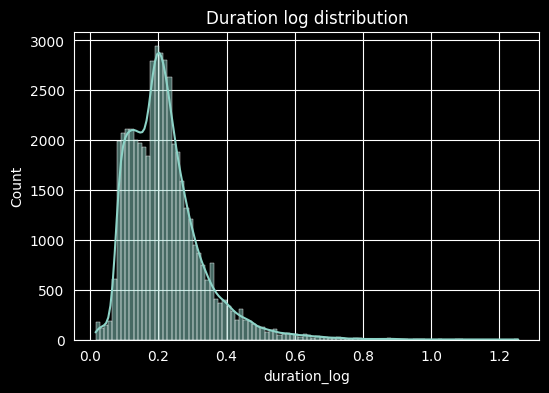

In [175]:
# Distance and duration are heavily right-skewed. Does scaling help?

feature_store["dist_log"] = np.log1p(feature_store["dist"])
dur_log = np.log1p(durations)

plt.figure(figsize=(6,4))
sns.histplot(feature_store["dist_log"], bins=100, kde=True)
plt.title("Distance log distribution")
plt.xlabel("distance_log")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(dur_log, bins=100, kde=True)
plt.title("Duration log distribution")
plt.xlabel("duration_log")
plt.show()

### Basic Correlations between Features

In [176]:
import os

features = []
targets = []

for path in scanpaths:
    df = load_csv(path)
    file_name = os.path.basename(path)
    try:
        rt = rt_dict[file_name]
    except:
        pass

    features.append([
        len(df),                      # number of fixations
        df["FPOGD"].mean(),
        df["FPOGD"].sum(),
        df["FPOGD"].std(),
        df["FPOGD"].max(),
    ])
    targets.append(rt)

features = np.array(features)
targets = np.array(targets)

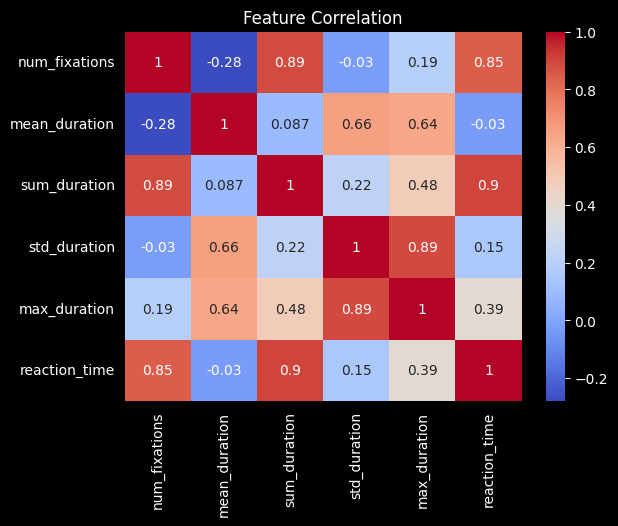

In [177]:
df_feat = pd.DataFrame(features, columns=[
    "num_fixations",
    "mean_duration",
    "sum_duration",
    "std_duration",
    "max_duration"
])
df_feat["reaction_time"] = targets

sns.heatmap(df_feat.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

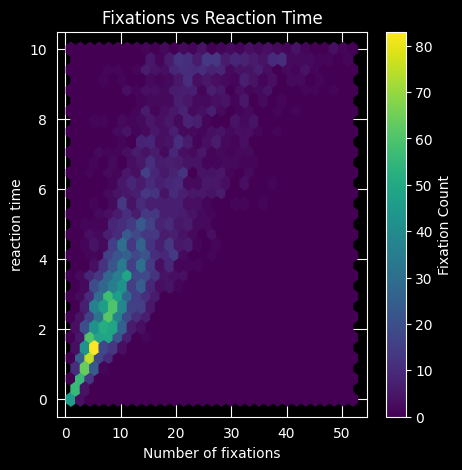

In [178]:
plt.figure(figsize=(5,5))
hb = plt.hexbin(df_feat["num_fixations"], df_feat["reaction_time"], gridsize=30, cmap='viridis')
plt.colorbar(hb, label="Fixation Count")
plt.title("Fixations vs Reaction Time")
plt.xlabel("Number of fixations")
plt.ylabel("reaction time")
plt.show()


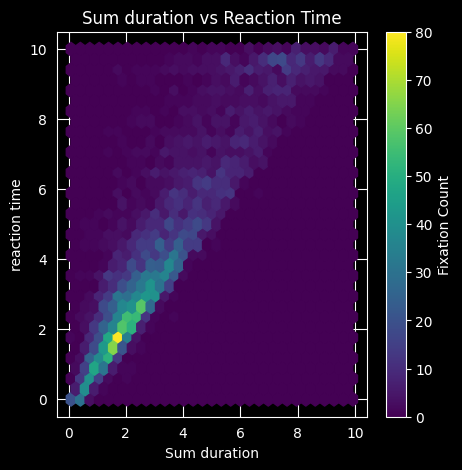

In [179]:
plt.figure(figsize=(5,5))
hb = plt.hexbin(df_feat["sum_duration"], df_feat["reaction_time"], gridsize=30, cmap='viridis')
plt.colorbar(hb, label="Fixation Count")
plt.title("Sum duration vs Reaction Time")
plt.xlabel("Sum duration")
plt.ylabel("reaction time")
plt.show()

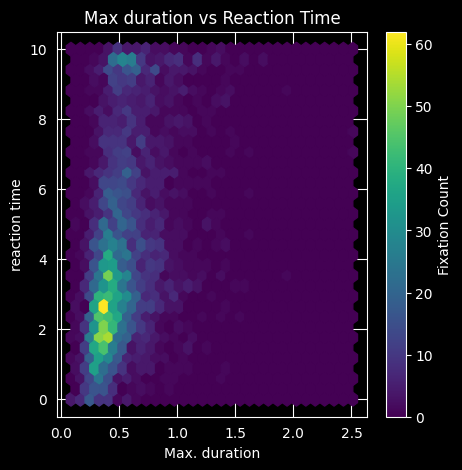

In [180]:
plt.figure(figsize=(5,5))
hb = plt.hexbin(df_feat["max_duration"], df_feat["reaction_time"], gridsize=30, cmap='viridis')
plt.colorbar(hb, label="Fixation Count")
plt.title("Max duration vs Reaction Time")
plt.xlabel("Max. duration")
plt.ylabel("reaction time")
plt.show()

Obviously, we have the more fixations the higher the reaction time.

Interestingly, the mean duration time is not so important, but the max_duration time is.

## Advanced correlation between features

### Distance features

In [181]:
def compute_step_distances(x, y):
    dx = np.diff(x, prepend=x[0])
    dy = np.diff(y, prepend=y[0])
    dist = np.sqrt(dx**2 + dy**2)
    return dist


def safe_corr(a, b):
    if len(a) < 2 or np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])


def distance_stats(dist):
    return {
        "dist_mean": float(dist.mean()),
        "dist_std": float(dist.std()),
        "dist_max": float(dist.max()),
        "dist_p10": float(np.percentile(dist, 10)),
        "dist_p50": float(np.percentile(dist, 50)),
        "dist_p90": float(np.percentile(dist, 90)),
        "dist_sum": float(dist.sum()),
        #"dist_count": len(dist) - 1   # First element is always 0
    }


def early_late_distance(dist, split=0.5):
    n = len(dist)
    split_idx = max(1, int(n * split))

    early = dist[:split_idx]
    late = dist[split_idx:]

    if len(late) == 0:
        late = dist[-1:]

    return {
        "early_mean_dist": float(early.mean()),
        "late_mean_dist": float(late.mean()),
        "early_late_ratio": float(early.mean() / (late.mean() + 1e-6)),
    }

def phase_features(dist):
    thirds = np.array_split(dist, 3)

    means = [t.mean() for t in thirds]
    sums = [t.sum() for t in thirds]

    return {
        "dist_phase1_sum": sums[0],
        "dist_phase1": means[0],
        "dist_phase2": means[1],
        "dist_phase3": means[2],
        "phase1_to_3_ratio": means[0] / (means[2] + 1e-6),
    }


def exploration_features(dist):
    threshold = np.percentile(dist, 75)
    large_jumps = dist > threshold
    switch_beh = np.mean( np.abs(np.diff(dist)) > threshold )   # How often jump size changes a lot

    return {
        "frac_large_jumps": float(large_jumps.mean()),
        "num_large_jumps": int(large_jumps.sum()),
        "large_jump_threshold": float(threshold),
        "switch_beh": float(switch_beh),
    }


def jump_autocorrelation(dist):
    return {
        "dist_autocorr": safe_corr(dist[:-1], dist[1:])
    }


def distance_trend(dist):
    if len(dist) < 2:
        return {"dist_trend": 0.0}

    t = np.arange(len(dist))
    slope = np.polyfit(t, dist, 1)[0]

    return {
        "dist_trend": float(slope)
    }

def variability_change(dist):
    half = len(dist) // 2

    early_std = dist[:half].std()
    late_std = dist[half:].std()

    return {
        "std_change": early_std - late_std
    }


def extract_distance_features_from_df(df, filename=None):
    df = df.copy()
    df.columns = [c.lower().strip() for c in df.columns]

    x = df["fpogx"].to_numpy(dtype=np.float32)
    y = df["fpogy"].to_numpy(dtype=np.float32)

    dist = compute_step_distances(x, y)

    features = {
        "filename": filename,
        "n_fixations": len(df),
    }

    features.update(distance_stats(dist))
    features.update(early_late_distance(dist))
    features.update(phase_features(dist))
    features.update(exploration_features(dist))
    features.update(jump_autocorrelation(dist))
    features.update(distance_trend(dist))
    features.update(variability_change(dist))

    return features

In [182]:
rows = []

for idx in range(len(scanpaths)):
    df = load_csv(scanpaths[idx])
    filename = os.path.basename(scanpaths[idx])

    features = extract_distance_features_from_df(df, filename)
    rows.append(features)

features_df = pd.DataFrame(rows)

eval_df = metadata.merge(features_df, on="filename", how="inner")

print(eval_df.shape)
eval_df.head()

/tmp/ipykernel_6383/3793567068.py:46: RuntimeWarning: Mean of empty slice
  means = [t.mean() for t in thirds]
/home/manzana/Data_Science/Uni/DL_Reaction_Time_HW/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/home/manzana/Data_Science/Uni/DL_Reaction_Time_HW/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/manzana/Data_Science/Uni/DL_Reaction_Time_HW/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/manzana/Data_Science/Uni/DL_Reaction_Time_HW/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/manzana/Data_Science/Uni/DL_Reaction_

(3696, 25)


,reaction_time,filename,n_fixations,dist_mean,dist_std,dist_max,dist_p10,dist_p50,dist_p90,dist_sum,...,dist_phase2,dist_phase3,phase1_to_3_ratio,frac_large_jumps,num_large_jumps,large_jump_threshold,switch_beh,dist_autocorr,dist_trend,std_change
0,3.73572,22-59.csv,7,0.287762,0.219730,0.544083,0.024849,0.321338,0.533872,2.014333,...,0.502428,0.072029,4.004939,0.285714,2,0.502428,0.000000,0.411001,-0.013551,0.006347
1,9.93164,39-75.csv,25,0.127710,0.095551,0.434122,0.028964,0.117103,0.241430,3.192752,...,0.198093,0.090771,1.079437,0.240000,6,0.161832,0.166667,0.087834,0.000082,0.032233
2,9.57226,12-109.csv,32,0.079797,0.080633,0.320014,0.009214,0.057682,0.178339,2.553511,...,0.084759,0.070302,1.187252,0.250000,8,0.103352,0.193548,0.302338,-0.000269,-0.034195
3,6.85913,1-91.csv,30,0.115371,0.151064,0.614483,0.012762,0.059237,0.299963,3.461124,...,0.071155,0.173925,0.580892,0.266667,8,0.146743,0.275862,-0.204963,0.004382,-0.110888
4,2.58795,37-49.csv,6,0.157550,0.148149,0.364456,0.006933,0.107205,0.358512,0.945301,...,0.236117,0.229600,0.030194,0.333333,2,0.294343,0.000000,0.405037,0.050240,-0.070992


In [183]:
feature_cols = [
    c for c in eval_df.columns
    if c not in ["reaction_time", "filename"]
]

corrs = []

for col in feature_cols:
    corr = eval_df[col].corr(eval_df["reaction_time"], method="spearman")
    corrs.append((col, corr))

corr_df = (
    pd.DataFrame(corrs, columns=["feature", "spearman_corr"])
    .sort_values("spearman_corr", key=lambda x: x.abs(), ascending=False)
)

print(corr_df)

                 feature  spearman_corr
0            n_fixations       0.873471
17       num_large_jumps       0.862306
7               dist_sum       0.851820
11       dist_phase1_sum       0.799098
21            dist_trend      -0.516001
12           dist_phase1       0.437726
8        early_mean_dist       0.430395
10      early_late_ratio       0.423796
3               dist_max       0.395449
15     phase1_to_3_ratio       0.310537
6               dist_p90       0.213457
2               dist_std       0.145806
16      frac_large_jumps      -0.141284
1              dist_mean       0.125838
19            switch_beh      -0.120491
18  large_jump_threshold       0.088329
20         dist_autocorr       0.084738
4               dist_p10       0.082115
14           dist_phase3      -0.052389
9         late_mean_dist      -0.044108
22            std_change       0.032147
13           dist_phase2      -0.027240
5               dist_p50       0.002296


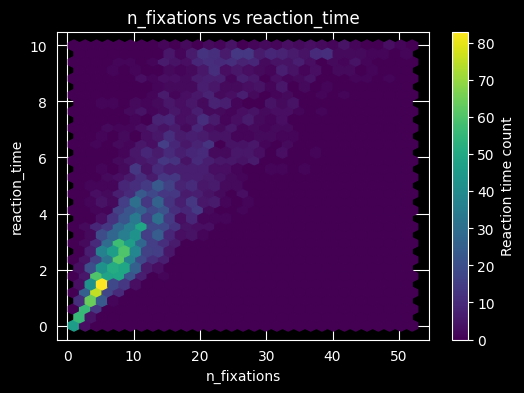

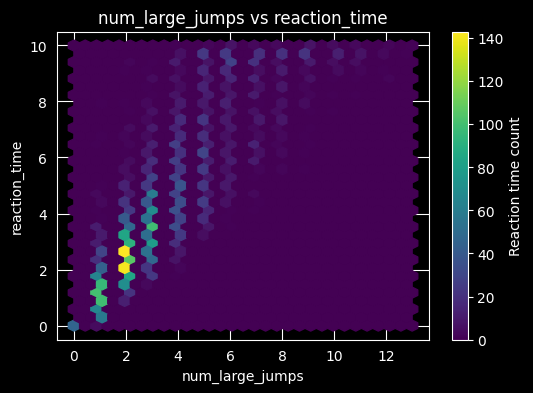

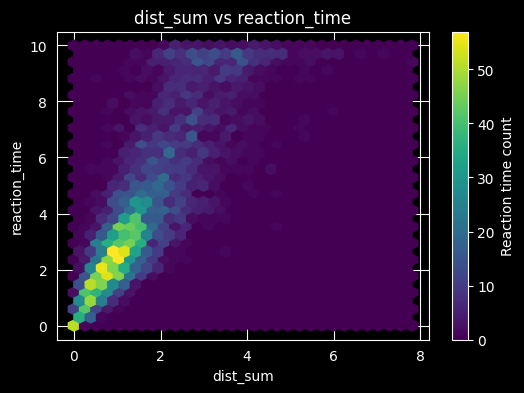

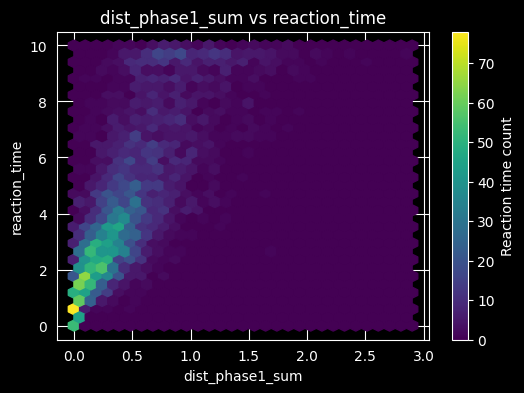

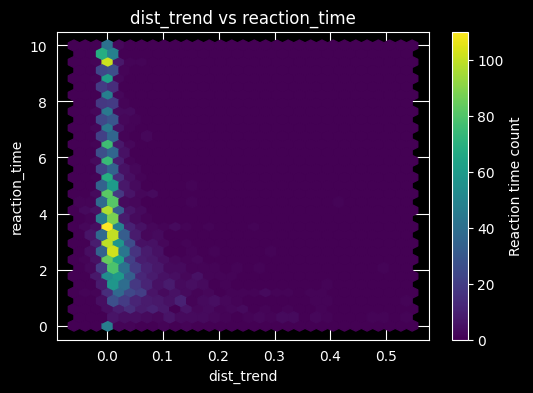

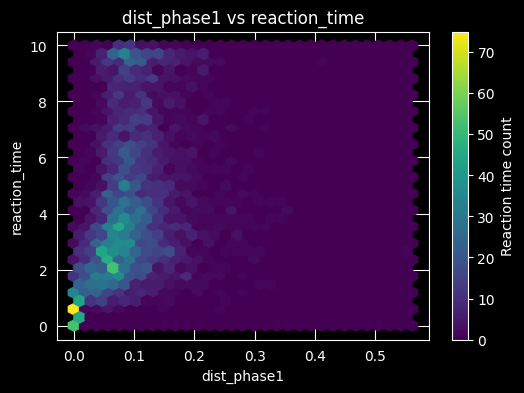

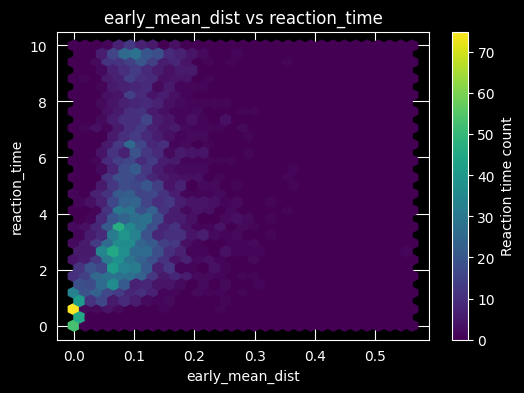

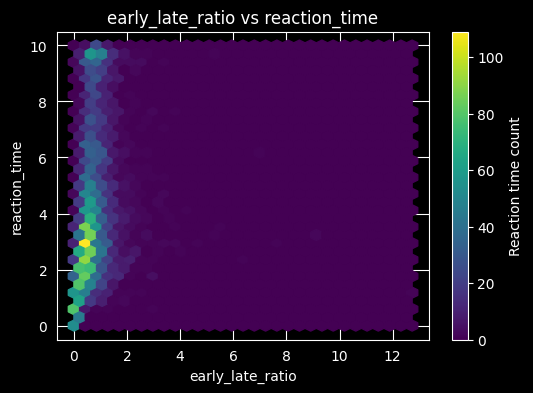

In [184]:
top_features = corr_df.head(8)["feature"].tolist()

for col in top_features:
    plt.figure(figsize=(6, 4))
    hb = plt.hexbin(eval_df[col], eval_df["reaction_time"], gridsize=30, cmap='viridis')
    plt.colorbar(hb, label="Reaction time count")
    #plt.scatter(eval_df[col], eval_df["reaction_time"], alpha=0.4)
    plt.xlabel(col)
    plt.ylabel("reaction_time")
    plt.title(f"{col} vs reaction_time")
    plt.show()

In [185]:
# Correlation between distance features and len(df)
selected_features = ["num_large_jumps",
                     "dist_sum",
                     "dist_max",
                     "dist_trend",
                     "dist_phase1",
                     "dist_phase1_sum"
                     ]

for col in selected_features:
    print(col, eval_df[col].corr(eval_df["n_fixations"]))

num_large_jumps 0.9915662739433853
dist_sum 0.852915168394979
dist_max 0.30350710090346905
dist_trend -0.3870838004648286
dist_phase1 0.2187870551495743
dist_phase1_sum 0.7780275049561323


num_large_jumps is a proxy for n_fixations. Shouldn't be used.

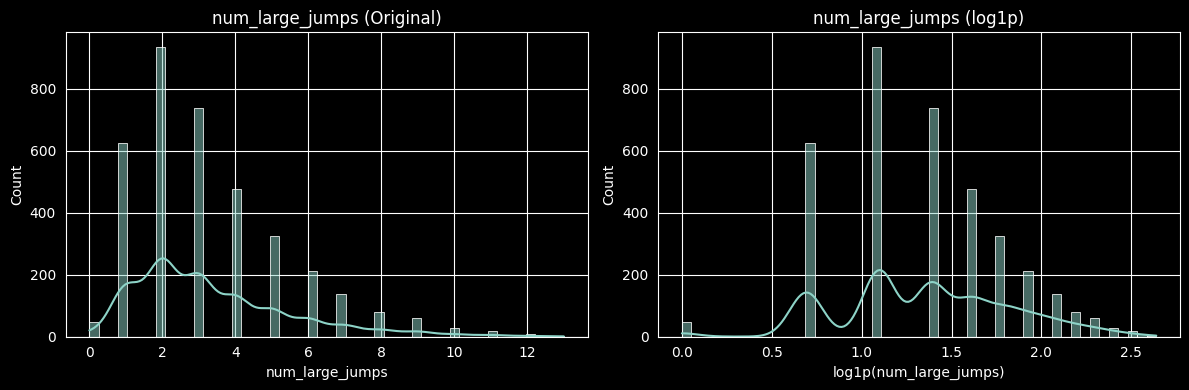

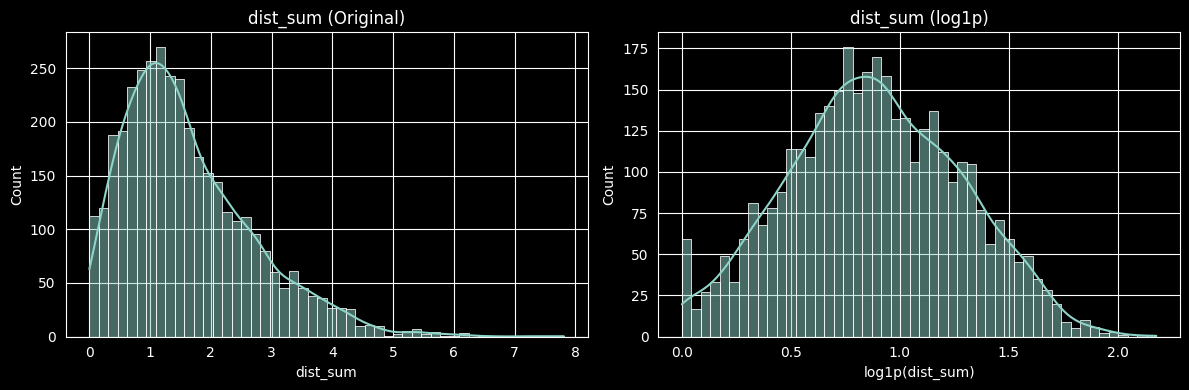

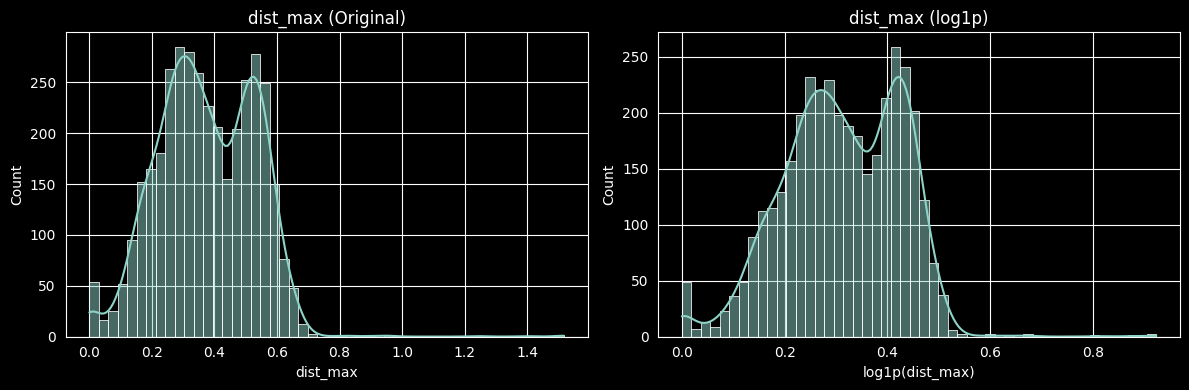

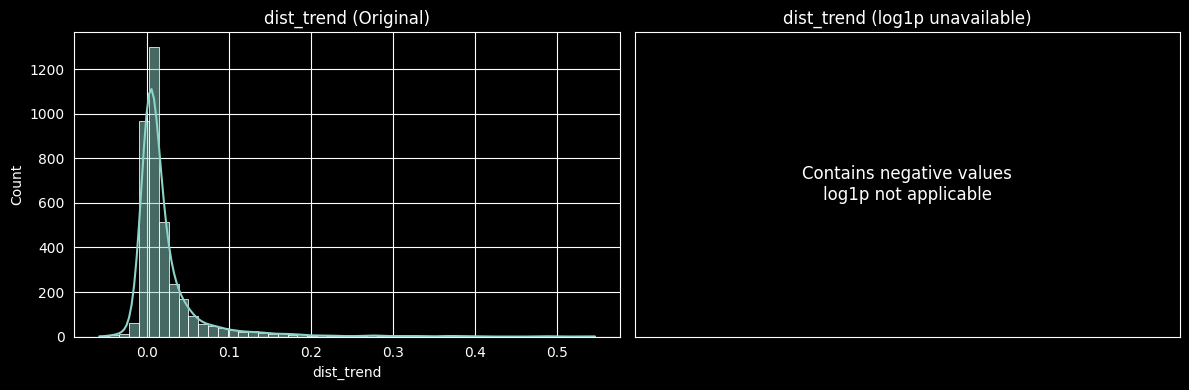

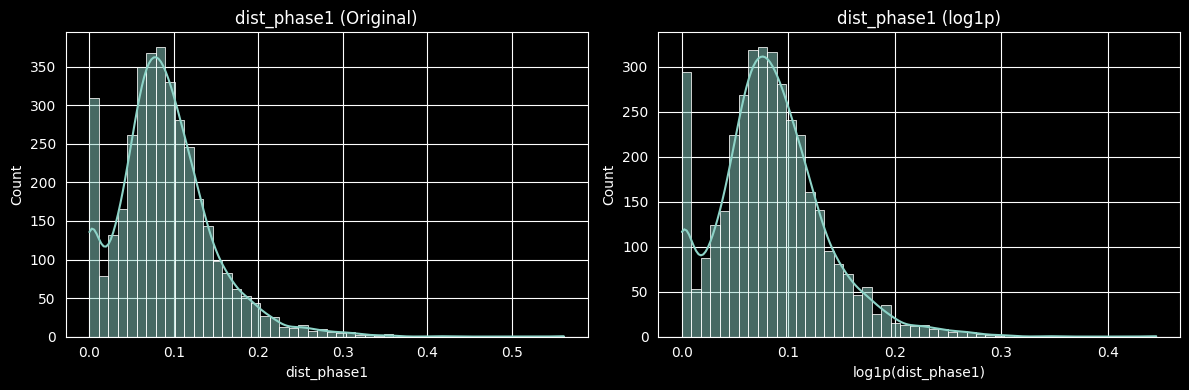

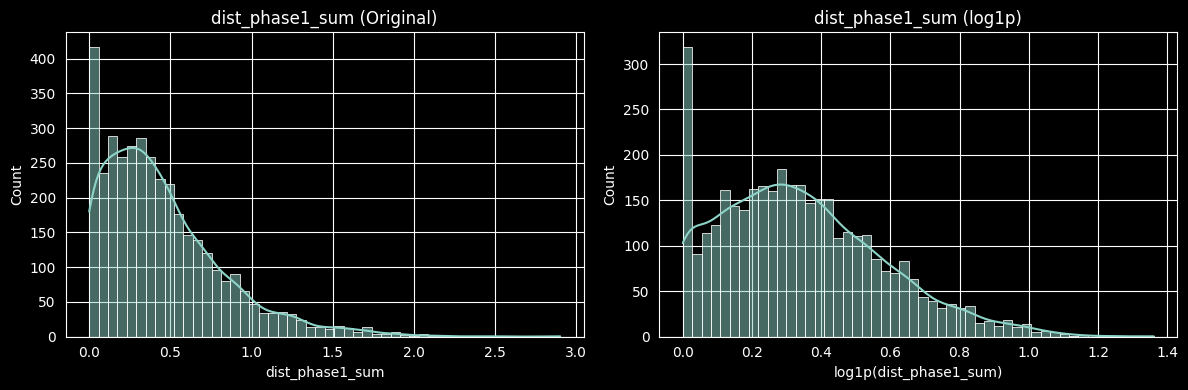

In [186]:
# Check distribution of selected features

# Histograms: original + log1p
for col in selected_features:
    values = eval_df[col].dropna().values

    # Only log-transform if all values are >= 0
    can_log = np.all(values >= 0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Original
    sns.histplot(values, bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} (Original)")
    axes[0].set_xlabel(col)

    # Log-transformed
    if can_log:
        log_values = np.log1p(values)
        sns.histplot(log_values, bins=50, kde=True, ax=axes[1])
        axes[1].set_title(f"{col} (log1p)")
        axes[1].set_xlabel(f"log1p({col})")
    else:
        axes[1].text(
            0.5,
            0.5,
            "Contains negative values\nlog1p not applicable",
            ha="center",
            va="center",
            fontsize=12,
        )
        axes[1].set_title(f"{col} (log1p unavailable)")
        axes[1].set_xticks([])
        axes[1].set_yticks([])

    plt.tight_layout()
    plt.show()

### Durations Analysis

In [187]:
def duration_basic_features(durations):
    return {
        "dur_mean": durations.mean(),
        "dur_std": durations.std(),
        "dur_max": durations.max(),
        "dur_p90": np.percentile(durations, 90),
        "dur_p10": np.percentile(durations, 10),
        "dur_p50": np.percentile(durations, 50),
        "dur_sum": durations.sum(),
    }

def duration_type_features(durations, short_thr, long_thr):
    # absolute
    short_abs = durations < short_thr
    long_abs  = durations > long_thr

    # relative
    p25 = np.percentile(durations, 25)
    p75 = np.percentile(durations, 75)

    short_rel = durations < p25
    long_rel  = durations > p75

    return {
        # absolute
        "num_short_abs": short_abs.sum(),
        "num_long_abs": long_abs.sum(),
        "frac_short_abs": short_abs.mean(),
        "frac_long_abs": long_abs.mean(),

        # relative
        "num_short_rel": short_rel.sum(),
        "num_long_rel": long_rel.sum(),
        "frac_short_rel": short_rel.mean(),
        "frac_long_rel": long_rel.mean(),
    }


def duration_trend(durations):
    x = np.arange(len(durations))
    if len(durations) < 2:
        return {"dur_trend": 0.0}

    slope = np.polyfit(x, durations, 1)[0]
    return {"dur_trend": slope}


def duration_phase_features(durations):
    n = len(durations)
    if n < 3:
        return {}

    p1 = durations[:n//3]
    p2 = durations[n//3:2*n//3]
    p3 = durations[2*n//3:]

    return {
        "dur_phase1_mean": p1.mean(),
        "dur_phase3_mean": p3.mean(),
        "dur_early_late_ratio": p1.mean() / (p3.mean() + 1e-6),
    }

def duration_instability(durations):
    diffs = np.abs(np.diff(durations))
    return {
        "dur_diff_mean": diffs.mean(),
        "dur_diff_std": diffs.std(),
    }

def duration_variability(durations):
    return {
        "dur_cv": durations.std() / (durations.mean() + 1e-6)
    }

def duration_efficiency(durations):
    n = len(durations)
    if n < 3:
        return {}

    early = durations[:n//3]
    late  = durations[2*n//3:]

    return {
        "dur_efficiency_score": late.mean() - early.mean()
    }

def duration_switches(durations, band=0.20):
    durations = np.asarray(durations, dtype=float)

    if len(durations) < 2:
        return {
            "dur_switches": 0,
            "dur_switch_rate": 0.0,
        }

    lower_q = 0.5 - band / 2
    upper_q = 0.5 + band / 2

    lower = np.quantile(durations, lower_q)
    upper = np.quantile(durations, upper_q)

    states = []
    current_state = durations[0] > np.median(durations)

    for d in durations:
        if d < lower:
            current_state = 0   # short
        elif d > upper:
            current_state = 1   # long
        # else: keep previous state

        states.append(current_state)

    states = np.asarray(states, dtype=int)
    switches = np.sum(states[1:] != states[:-1])

    return {
        "dur_switches": switches,
        "dur_switch_rate": switches / (len(durations) - 1),
        "dur_lower": lower,
        "dur_upper": upper,
    }

# Next two functions for temporal asymmetry
def duration_switch_drop(durations):
    n = len(durations)
    if n < 6:
        return {"dur_switch_drop": 0.0}

    median = np.median(durations)
    binary = durations > median
    switches = (binary[1:] != binary[:-1]).astype(int)

    early = switches[:len(switches)//2]
    late  = switches[len(switches)//2:]

    return {
        "dur_switch_drop": early.mean() - late.mean()
    }

def duration_chaos_drop(durations):
    n = len(durations)
    if n < 6:
        return {"dur_chaos_drop": 0.0}

    diffs = np.abs(np.diff(durations))

    early = diffs[:len(diffs)//2]
    late  = diffs[len(diffs)//2:]

    return {
        "dur_chaos_drop": early.mean() - late.mean()
    }

In [188]:
# All durations for the threshold
all_durations = []

for path in scanpaths:
    df = load_csv(path)
    durations = df["FPOGD"].values
    all_durations.append(durations)

all_durations = np.concatenate(all_durations)

short_thr = np.quantile(all_durations, 0.25)
long_thr  = np.quantile(all_durations, 0.75)

print(f"Global SHORT threshold (25%): {short_thr:.4f}")
print(f"Global LONG threshold  (75%): {long_thr:.4f}")

Global SHORT threshold (25%): 0.1539
Global LONG threshold  (75%): 0.3070


In [189]:
# log_durations = np.log(all_durations + 1e-6)
#
# short_thr = np.quantile(log_durations, 0.25)
# long_thr  = np.quantile(log_durations, 0.75)
#
# log_d = np.log(durations + 1e-6)
#
# short = log_d < short_thr
# long  = log_d > long_thr
#
# print(f"Global SHORT threshold (25%): {short_thr:.4f}")
# print(f"Global LONG threshold  (75%): {long_thr:.4f}")

In [190]:

def extract_duration_features_from_df(df, filename=None):
    df = df.copy()

    durations = df["FPOGD"].values

    features = {
        "filename": filename,
        "n_fixations": len(df),
    }

    features.update(duration_basic_features(durations))
    features.update(duration_type_features(durations, short_thr=short_thr, long_thr=long_thr))
    features.update(duration_trend(durations))
    features.update(duration_phase_features(durations))
    features.update(duration_instability(durations))
    features.update(duration_variability(durations))
    features.update(duration_switches(durations))
    features.update(duration_efficiency(durations))
    features.update(duration_chaos_drop(durations))
    features.update(duration_switch_drop(durations))

    return features

In [191]:
rows = []

for idx in range(len(scanpaths)):
    df = load_csv(scanpaths[idx])
    filename = os.path.basename(scanpaths[idx])

    features = extract_duration_features_from_df(df, filename)
    rows.append(features)

features_df = pd.DataFrame(rows)

eval_df = metadata.merge(features_df, on="filename", how="inner")

print(eval_df.shape)
eval_df.head()

/tmp/ipykernel_6383/4129607065.py:66: RuntimeWarning: Mean of empty slice
  "dur_diff_mean": diffs.mean(),
/home/manzana/Data_Science/Uni/DL_Reaction_Time_HW/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/manzana/Data_Science/Uni/DL_Reaction_Time_HW/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/manzana/Data_Science/Uni/DL_Reaction_Time_HW/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/manzana/Data_Science/Uni/DL_Reaction_Time_HW/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(3696, 32)


,reaction_time,filename,n_fixations,dur_mean,dur_std,dur_max,dur_p90,dur_p10,dur_p50,dur_sum,...,dur_diff_mean,dur_diff_std,dur_cv,dur_switches,dur_switch_rate,dur_lower,dur_upper,dur_efficiency_score,dur_chaos_drop,dur_switch_drop
0,3.73572,22-59.csv,7,0.263270,0.114627,0.48486,0.388254,0.148388,0.242920,1.84289,...,0.142985,0.128398,0.435396,2,0.333333,0.242698,0.261892,-0.167458,0.199130,0.000000
1,9.93164,39-75.csv,25,0.281402,0.099752,0.61426,0.355932,0.210210,0.258670,7.03504,...,0.104419,0.127261,0.354482,11,0.458333,0.252096,0.274948,0.002162,0.052452,-0.083333
2,9.57226,12-109.csv,32,0.180785,0.087826,0.46094,0.295507,0.102146,0.153320,5.78513,...,0.088396,0.067440,0.485802,13,0.419355,0.132810,0.193748,-0.089402,0.061083,0.100000
3,6.85913,1-91.csv,30,0.195773,0.091787,0.50708,0.295951,0.113243,0.170840,5.87318,...,0.091671,0.072768,0.468844,10,0.344828,0.160718,0.189674,0.028699,-0.023962,0.033333
4,2.58795,37-49.csv,6,0.275015,0.066753,0.33997,0.339875,0.186005,0.299165,1.65009,...,0.087442,0.060221,0.242725,2,0.400000,0.274900,0.323430,0.040250,-0.010487,-0.166667


In [192]:
feature_cols = [
    c for c in eval_df.columns
    if c not in ["reaction_time", "filename"]
]

corrs = []

for col in feature_cols:
    corr = eval_df[col].corr(eval_df["reaction_time"], method="spearman")
    corrs.append((col, corr))

corr_df = (
    pd.DataFrame(corrs, columns=["feature", "spearman_corr"])
    .sort_values("spearman_corr", key=lambda x: x.abs(), ascending=False)
)

corr_df
print(corr_df)

                 feature  spearman_corr
7                dur_sum       0.902362
0            n_fixations       0.873471
13          num_long_rel       0.860240
12         num_short_rel       0.858560
23          dur_switches       0.769901
9           num_long_abs       0.659601
3                dur_max       0.439715
8          num_short_abs       0.437962
21          dur_diff_std       0.409095
22                dur_cv       0.379734
2                dur_std       0.335319
5                dur_p10      -0.245809
24       dur_switch_rate      -0.203604
4                dur_p90       0.191588
10        frac_short_abs       0.170802
20         dur_diff_mean       0.167564
14        frac_short_rel      -0.152022
27  dur_efficiency_score       0.140449
19  dur_early_late_ratio      -0.139386
15         frac_long_rel      -0.138200
25             dur_lower      -0.136137
16             dur_trend       0.115763
6                dur_p50      -0.098344
28        dur_chaos_drop      -0.089603


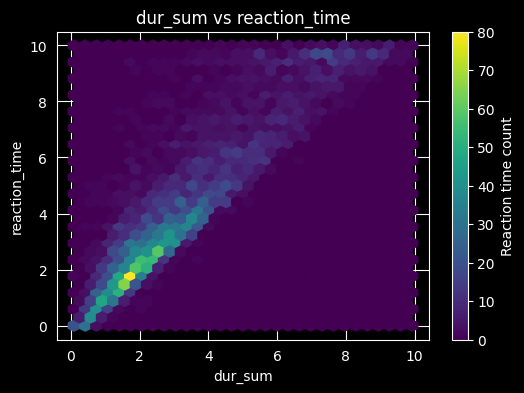

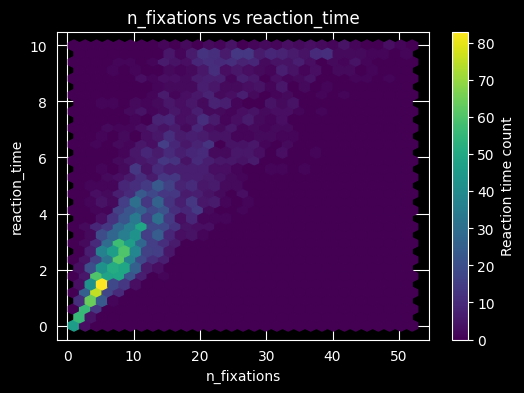

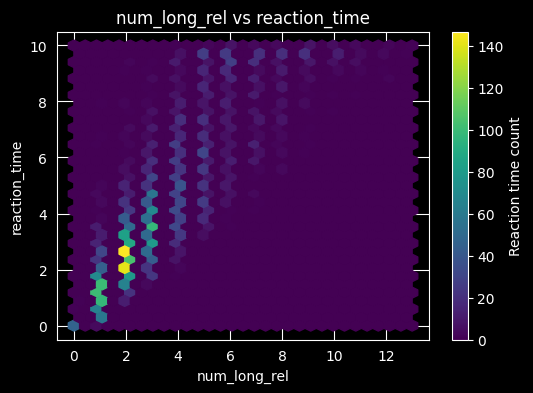

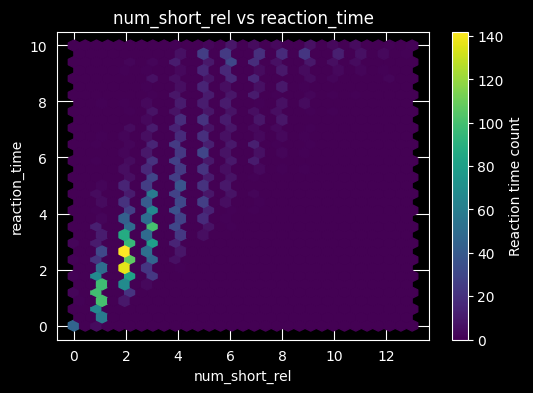

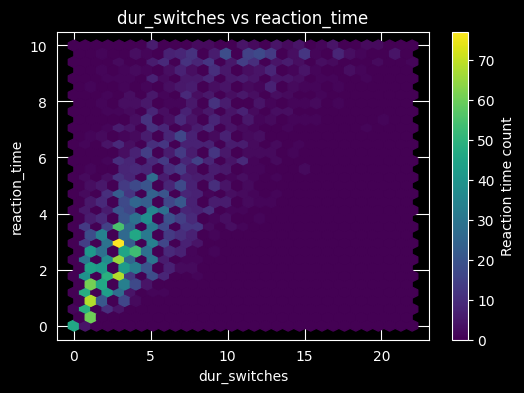

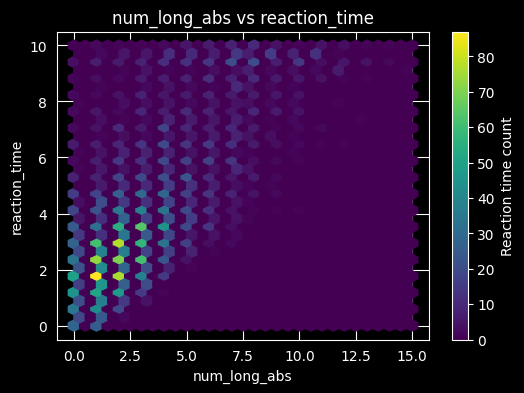

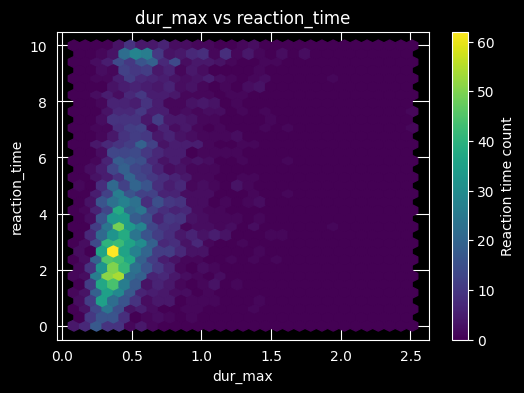

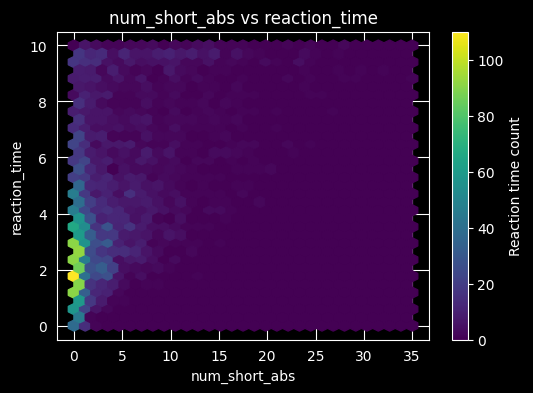

In [193]:
top_features = corr_df.head(8)["feature"].tolist()

for col in top_features:
    plt.figure(figsize=(6, 4))
    hb = plt.hexbin(eval_df[col], eval_df["reaction_time"], gridsize=30, cmap='viridis')
    plt.colorbar(hb, label="Reaction time count")
    #plt.scatter(eval_df[col], eval_df["reaction_time"], alpha=0.4)
    plt.xlabel(col)
    plt.ylabel("reaction_time")
    plt.title(f"{col} vs reaction_time")
    plt.show()

In [194]:
# Check correlation between best duration features and n_fixations

selected_features = ["dur_sum",
                     "dur_max",
                     "dur_diff_std",
                     "dur_switches",
                     ]

for col in selected_features:
    print(col, eval_df[col].corr(eval_df["n_fixations"]))

dur_sum 0.8898286145914943
dur_max 0.1936658053716193
dur_diff_std 0.12499095228423279
dur_switches 0.8899144988248378


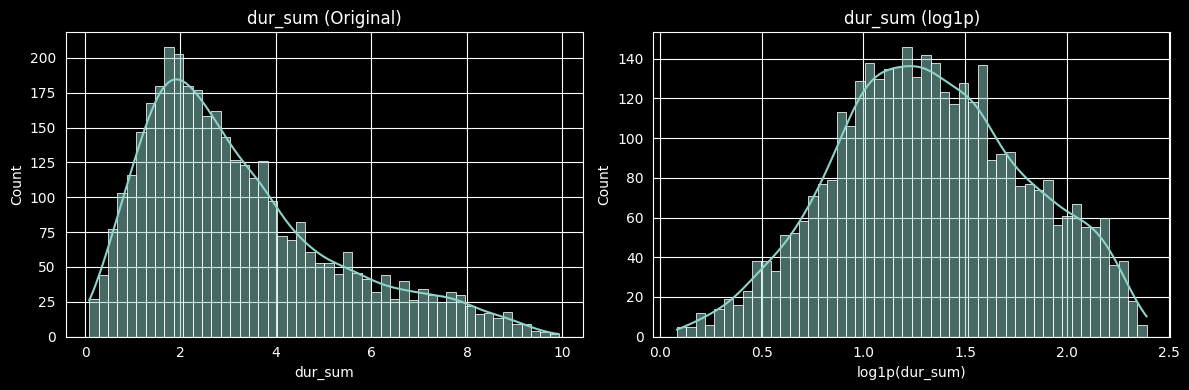

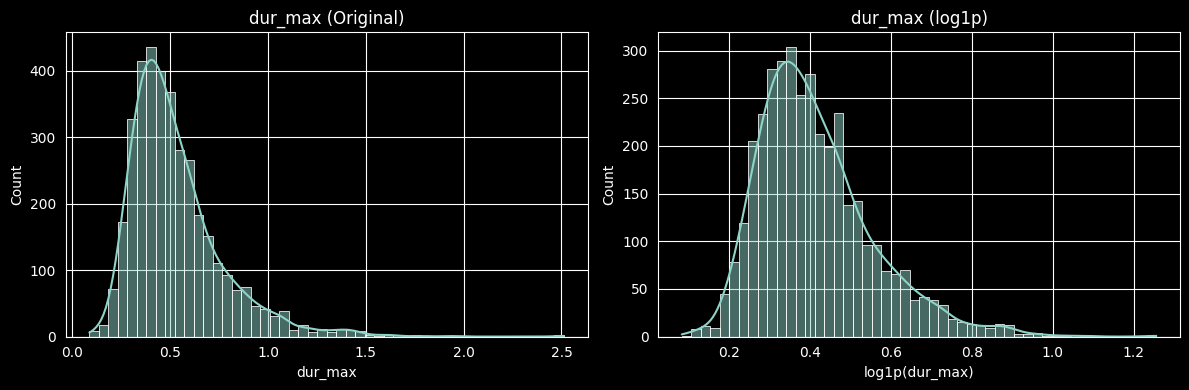

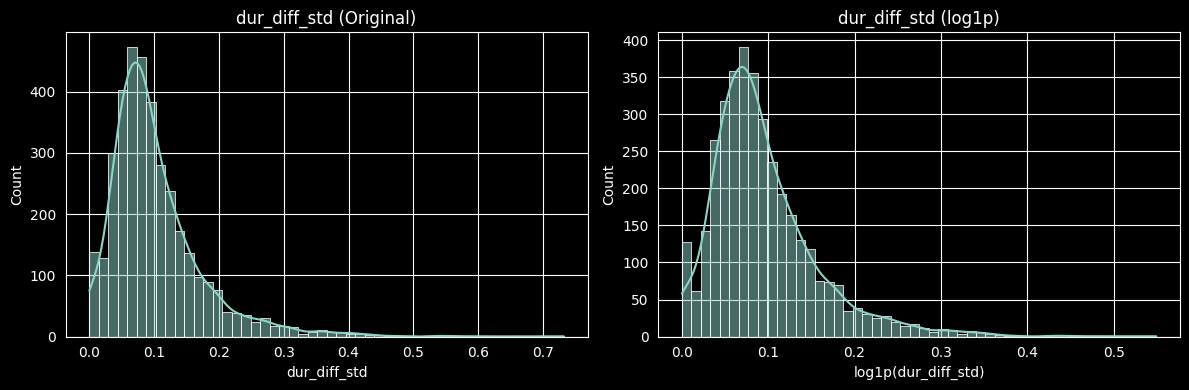

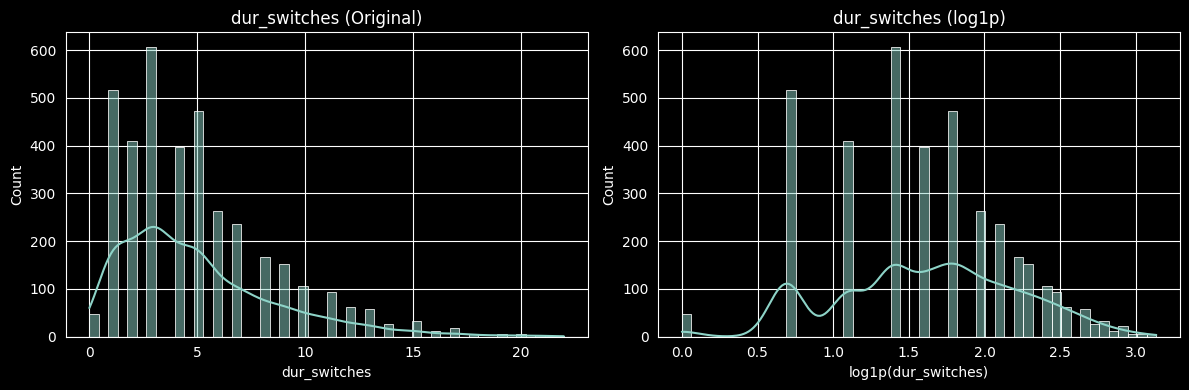

In [195]:
# Check distribution of selected features

# Histograms: original + log1p
for col in selected_features:
    values = eval_df[col].dropna().values

    # Only log-transform if all values are >= 0
    can_log = np.all(values >= 0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Original
    sns.histplot(values, bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} (Original)")
    axes[0].set_xlabel(col)

    # Log-transformed
    if can_log:
        log_values = np.log1p(values)
        sns.histplot(log_values, bins=50, kde=True, ax=axes[1])
        axes[1].set_title(f"{col} (log1p)")
        axes[1].set_xlabel(f"log1p({col})")
    else:
        axes[1].text(
            0.5,
            0.5,
            "Contains negative values\nlog1p not applicable",
            ha="center",
            va="center",
            fontsize=12,
        )
        axes[1].set_title(f"{col} (log1p unavailable)")
        axes[1].set_xticks([])
        axes[1].set_yticks([])

    plt.tight_layout()
    plt.show()

## Spatial features

In [196]:
from itertools import combinations
from scipy.spatial import ConvexHull

In [197]:
def safe_std(x):
    return float(np.std(x)) if len(x) > 1 else 0.0


def safe_corr(a, b):
    if len(a) < 2 or np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])


def compute_grid_cells(x, y, grid_size=10):
    # If 10x10 grid: 100 cells. Then, x and y are in [0, 1], so
    # we can do int(x * 10) to get cell, e.g. 3.4 -> cell 3.
    # Return two positions x and y in single value by 1G*y + x, which gives coords
    x_idx = np.clip((x * grid_size).astype(int), 0, grid_size - 1)
    y_idx = np.clip((y * grid_size).astype(int), 0, grid_size - 1)
    return y_idx * grid_size + x_idx

In [198]:
def revisit_features(x, y, grid_size=10):
    cells = compute_grid_cells(x, y, grid_size)
    total_visits = len(cells)
    unique_cells = len(np.unique(cells))
    revisits = total_visits - unique_cells

    return {
        "spatial_unique_cells": unique_cells,
        "spatial_revisits": revisits,
        "spatial_revisit_ratio": revisits / (total_visits + 1e-6),
        "spatial_coverage_ratio": unique_cells / (grid_size * grid_size),
    }


def spatial_entropy_features(x, y, grid_size=10):
    cells = compute_grid_cells(x, y, grid_size)
    counts = np.bincount(cells, minlength=grid_size * grid_size).astype(float)

    p = counts / (counts.sum() + 1e-6)
    p_nonzero = p[p > 0]

    entropy = -np.sum(p_nonzero * np.log(p_nonzero))
    max_entropy = np.log(grid_size * grid_size)

    return {
        "spatial_entropy": float(entropy),
        "spatial_entropy_norm": float(entropy / (max_entropy + 1e-6)),
    }


def convex_hull_features(x, y):
    points = np.column_stack([x, y])

    if len(points) < 3:
        return {
            "spatial_hull_area": 0.0,
        }

    try:
        hull = ConvexHull(points)
        area = hull.volume   # In 2D, scipy stores polygon area in .volume
    except:
        area = 0.0

    return {
        "spatial_hull_area": float(area),
    }


def mean_pairwise_distance_features(x, y, max_points=300):
    points = np.column_stack([x, y])

    # Avoid O(n^2) explosion for very long scanpaths
    if len(points) > max_points:
        idx = np.linspace(0, len(points) - 1, max_points).astype(int)
        points = points[idx]

    n = len(points)
    if n < 2:
        return {
            "spatial_pairwise_dist_mean": 0.0,
            "spatial_pairwise_dist_std": 0.0,
        }

    dists = []

    for i, j in combinations(range(n), 2):
        d = np.linalg.norm(points[i] - points[j])
        dists.append(d)

    dists = np.array(dists)

    return {
        "spatial_pairwise_dist_mean": float(dists.mean()),
        "spatial_pairwise_dist_std": float(dists.std()),
    }

def direction_consistency_features(x, y):
    dx = np.diff(x)
    dy = np.diff(y)

    step_len = np.sqrt(dx**2 + dy**2)
    valid = step_len > 1e-8

    dx = dx[valid]
    dy = dy[valid]
    step_len = step_len[valid]

    if len(step_len) < 2:
        return {
            "spatial_direction_consistency": 0.0,
            "spatial_angle_std": 0.0,
            "spatial_turn_mean_abs": 0.0,
        }

    ux = dx / step_len
    uy = dy / step_len

    cos_sim = ux[:-1] * ux[1:] + uy[:-1] * uy[1:]
    direction_consistency = np.mean(cos_sim)

    angles = np.arctan2(dy, dx)
    angles_unwrapped = np.unwrap(angles)
    turns = np.diff(angles_unwrapped)

    return {
        "spatial_direction_consistency": float(direction_consistency),
        "spatial_angle_std": float(np.std(angles_unwrapped)),
        "spatial_turn_mean_abs": float(np.mean(np.abs(turns))),
    }


def sweep_features(x, y):
    dx = np.diff(x)
    dy = np.diff(y)

    if len(dx) < 2:
        return {
            "spatial_x_sweep_consistency": 0.0,
            "spatial_y_sweep_consistency": 0.0,
            "spatial_main_axis_sweep": 0.0,
            "spatial_x_progress_corr": 0.0,
            "spatial_y_progress_corr": 0.0,
        }

    eps = 1e-6

    x_sign = np.sign(dx[np.abs(dx) > eps])
    y_sign = np.sign(dy[np.abs(dy) > eps])

    x_sweep = np.abs(np.mean(x_sign)) if len(x_sign) > 0 else 0.0
    y_sweep = np.abs(np.mean(y_sign)) if len(y_sign) > 0 else 0.0

    t = np.arange(len(x))

    return {
        "spatial_x_sweep_consistency": float(x_sweep),
        "spatial_y_sweep_consistency": float(y_sweep),
        "spatial_main_axis_sweep": float(max(x_sweep, y_sweep)),
        "spatial_x_progress_corr": safe_corr(t, x),
        "spatial_y_progress_corr": safe_corr(t, y),
    }

In [199]:
def extract_spatial_features_from_df(df, filename=None, grid_size=10):
    df = df.copy()
    df.columns = [c.lower().strip() for c in df.columns]

    x = df["fpogx"].to_numpy(dtype=np.float32)
    y = df["fpogy"].to_numpy(dtype=np.float32)

    features = {
        "filename": filename,
        "n_fixations": len(df),
    }

    features.update(revisit_features(x, y, grid_size=grid_size))
    features.update(spatial_entropy_features(x, y, grid_size=grid_size))
    features.update(convex_hull_features(x, y))
    features.update(mean_pairwise_distance_features(x, y))
    features.update(direction_consistency_features(x, y))
    features.update(sweep_features(x, y))

    return features

In [200]:
rows = []

for idx in range(len(scanpaths)):
    df = load_csv(scanpaths[idx])
    filename = os.path.basename(scanpaths[idx])

    features = extract_spatial_features_from_df(
        df,
        filename=filename,
        grid_size=10,
    )
    rows.append(features)

spatial_features_df = pd.DataFrame(rows)

spatial_eval_df = metadata.merge(spatial_features_df, on="filename", how="inner")

print(spatial_eval_df.shape)
spatial_eval_df.head()

(3696, 20)


,reaction_time,filename,n_fixations,spatial_unique_cells,spatial_revisits,spatial_revisit_ratio,spatial_coverage_ratio,spatial_entropy,spatial_entropy_norm,spatial_hull_area,spatial_pairwise_dist_mean,spatial_pairwise_dist_std,spatial_direction_consistency,spatial_angle_std,spatial_turn_mean_abs,spatial_x_sweep_consistency,spatial_y_sweep_consistency,spatial_main_axis_sweep,spatial_x_progress_corr,spatial_y_progress_corr
0,3.73572,22-59.csv,7,5,2,0.285714,0.05,1.549826,0.336540,0.066770,0.294271,0.159118,-0.560143,1.969947,2.422706,0.000000,0.333333,0.333333,-0.174096,-0.529127
1,9.93164,39-75.csv,25,12,13,0.520000,0.12,2.209477,0.479782,0.126586,0.196716,0.125316,-0.121070,2.403151,1.726431,0.083333,0.083333,0.083333,0.106558,0.002106
2,9.57226,12-109.csv,32,7,25,0.781250,0.07,1.390333,0.301907,0.040149,0.130630,0.110999,-0.232403,6.136705,1.892290,0.096774,0.096774,0.096774,-0.402489,-0.559471
3,6.85913,1-91.csv,30,10,20,0.666667,0.10,1.978778,0.429686,0.147736,0.277216,0.160119,-0.008187,7.904634,1.576859,0.172414,0.034483,0.172414,0.119793,-0.038874
4,2.58795,37-49.csv,6,3,3,0.500000,0.03,1.011404,0.219624,0.018264,0.190352,0.164007,-0.051463,2.158204,1.686695,0.200000,0.200000,0.200000,0.332556,-0.187304


In [201]:
feature_cols = [
    c for c in spatial_eval_df.columns
    if c not in ["reaction_time", "filename"]
]

corrs = []

for col in feature_cols:
    corr = spatial_eval_df[col].corr(
        spatial_eval_df["reaction_time"],
        method="spearman"
    )
    corrs.append((col, corr))

spatial_corr_df = (
    pd.DataFrame(corrs, columns=["feature", "spearman_corr"])
    .sort_values("spearman_corr", key=lambda x: x.abs(), ascending=False)
)

spatial_corr_df
#print(spatial_corr_df)

,feature,spearman_corr
0,n_fixations,0.873471
2,spatial_revisits,0.816397
1,spatial_unique_cells,0.773933
4,spatial_coverage_ratio,0.773933
5,spatial_entropy,0.687694
6,spatial_entropy_norm,0.687690
11,spatial_angle_std,0.684293
3,spatial_revisit_ratio,0.665448
7,spatial_hull_area,0.635159
9,spatial_pairwise_dist_std,0.340714


Favorite features:
* spatial revisits, even though I'd prefer spatial_revisit_ratio, since the other one correlates with number of fixations
* spatial_coverage_ratio
* Spatial_entropy_norm
* spatial_angle_std.
* spatial_hull_area

I need to check whether they actually correlate with n_fixations, though.
Code below suggests that all of them yes correlate, but not so much, except for spatial_coverage_ratio (which makes sense, the more points you have, the better). I'll mark that one as optional. Of course, spatial_revisits highly correlates, as expected, so better to take the ratio.

In [207]:
selected_features = ["spatial_revisit_ratio",
                     "spatial_revisits",
                     "spatial_coverage_ratio",
                     "spatial_entropy_norm",
                     "spatial_angle_std",
                     "spatial_hull_area"
                     ]

for col in selected_features:
    print(col, spatial_eval_df[col].corr(spatial_eval_df["n_fixations"]))

spatial_revisit_ratio 0.7362013428042347
spatial_revisits 0.9619456646578659
spatial_coverage_ratio 0.81757684917289
spatial_entropy_norm 0.665531835505289
spatial_angle_std 0.6611979954492039
spatial_hull_area 0.5986747111642219


In [206]:
top_features = spatial_corr_df.head(8)["feature"].tolist()

for col in top_features:
    plt.figure(figsize=(6, 4))
    hb = plt.hexbin(spatial_eval_df[col], spatial_eval_df["reaction_time"], gridsize=30, cmap='viridis')
    plt.colorbar(hb, label="Reaction time count")
    plt.xlabel(col)
    plt.ylabel("reaction_time")
    plt.title(f"{col} vs reaction_time")
    plt.show()


KeyboardInterrupt



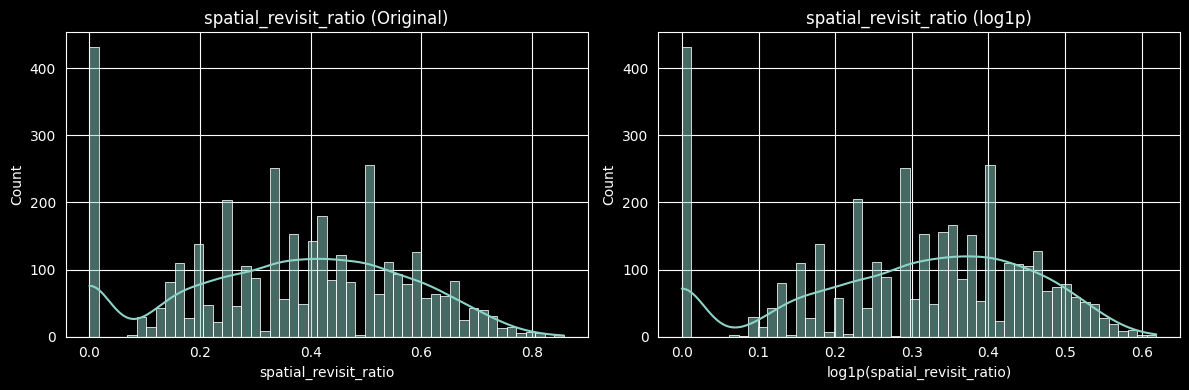

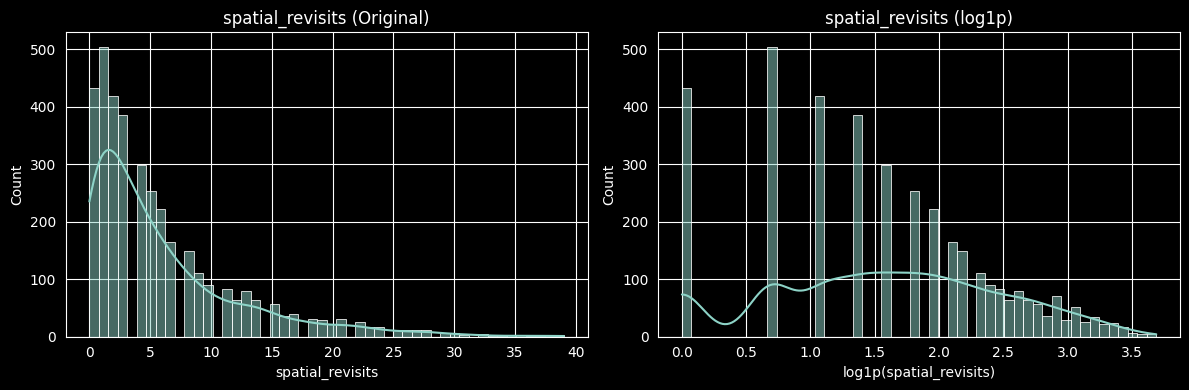

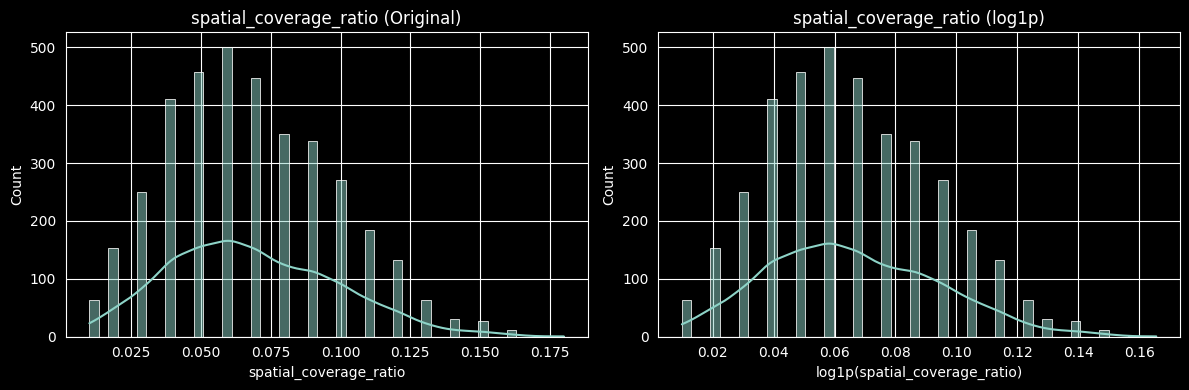

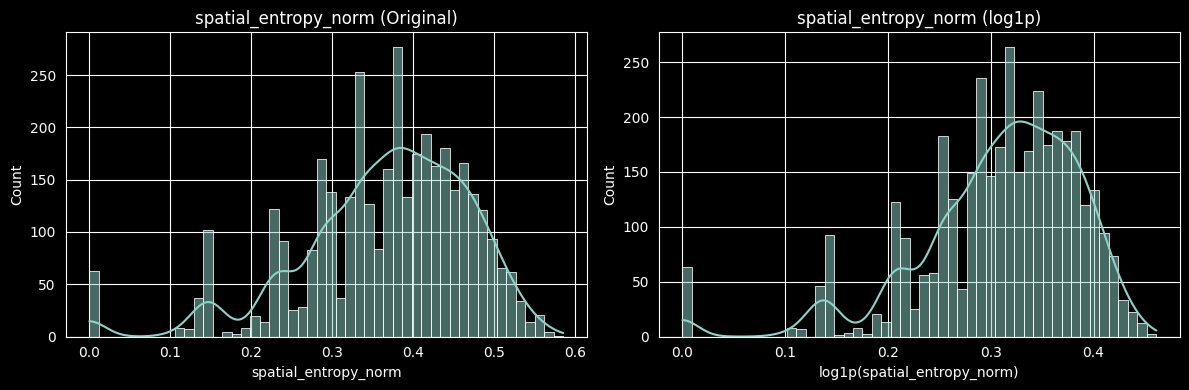

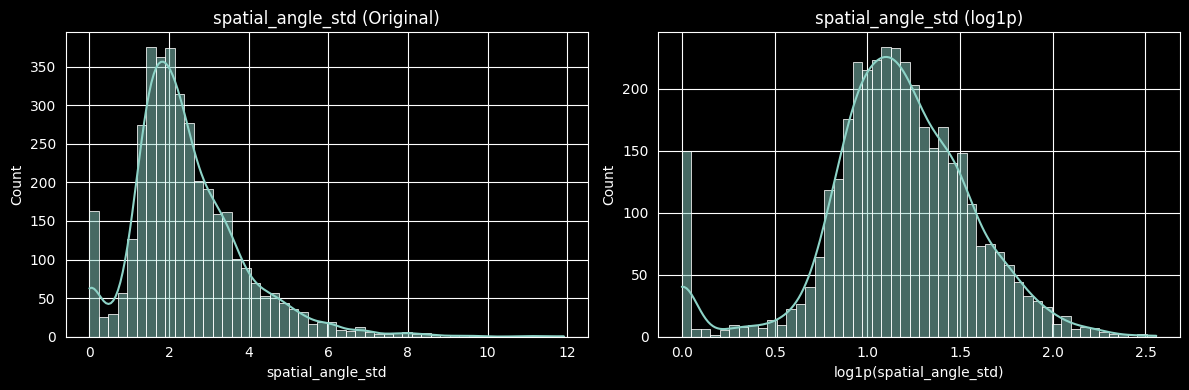

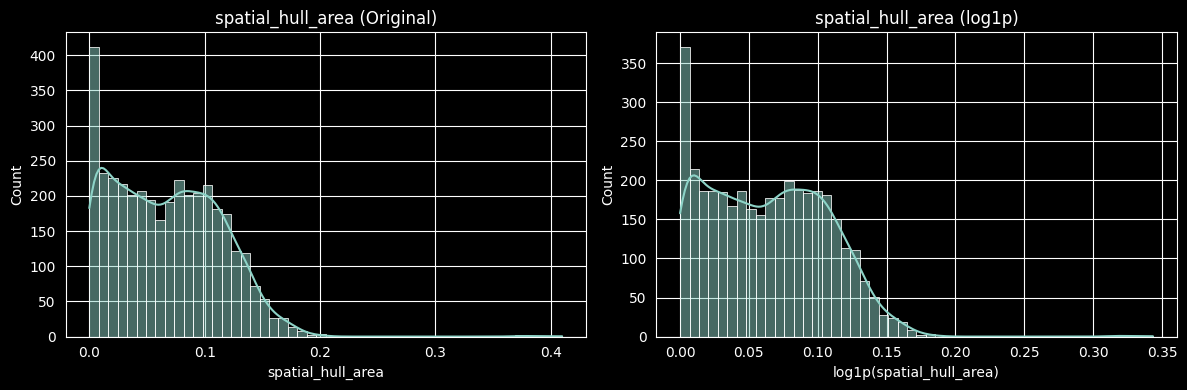

In [210]:
# Check distribution of selected features

# Histograms: original + log1p
for col in selected_features:
    values = spatial_eval_df[col].dropna().values

    # Only log-transform if all values are >= 0
    can_log = np.all(values >= 0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Original
    sns.histplot(values, bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} (Original)")
    axes[0].set_xlabel(col)

    # Log-transformed
    if can_log:
        log_values = np.log1p(values)
        sns.histplot(log_values, bins=50, kde=True, ax=axes[1])
        axes[1].set_title(f"{col} (log1p)")
        axes[1].set_xlabel(f"log1p({col})")
    else:
        axes[1].text(
            0.5,
            0.5,
            "Contains negative values\nlog1p not applicable",
            ha="center",
            va="center",
            fontsize=12,
        )
        axes[1].set_title(f"{col} (log1p unavailable)")
        axes[1].set_xticks([])
        axes[1].set_yticks([])

    plt.tight_layout()
    plt.show()

## Other analysis

In [ ]:
# I saw a sequence with a single point having 0s. Is this always the case?
rows = []
for idx in range(len(scanpaths)):
    df = load_csv(scanpaths[idx])
    filename = os.path.basename(scanpaths[idx])
    single_point = False
    if len(df) == 1:
        single_point = True
    rows.append({
        "filename": filename,
        "single_point": single_point
    })

In [ ]:
single_point_df = pd.DataFrame(rows)
single_point_df = metadata.merge(single_point_df, on="filename", how="inner")

#print(single_point_df[single_point_df["single_point"] == True])
print(single_point_df[single_point_df["reaction_time"]==0.0])

46 occurrences where reaction time is 0.0 -> Always length of sequence = 1

## Split reaction times into different regions

In [41]:
# Todo: Look into multimodality, once I have important input features identified.
#fixation count
#duration
#path length
low_rt  = df_feat[df_feat["reaction_time"] < 4.5]
mid_rt  = df_feat[(df_feat["reaction_time"] >= 4.5) & (df_feat["reaction_time"] < 8)]
high_rt = df_feat[df_feat["reaction_time"] >= 8]

### Ideas

* Distanz Start- zu Endpunkt
* Summe der Durationpoints
* Einzelner Punkt: Da waren es 0s